In [22]:
from pathlib import Path
import pandas as pd

data_dir = Path("Data_files")
df_dict = {}

for file_path in sorted(data_dir.rglob("*")):
    if file_path.is_file() and file_path.stem.endswith("NOFLAG"):
        folder_name = str(file_path.parent.relative_to(data_dir))
        # df_dict[folder_name] = pd.read_csv(file_path)
        print(f"## {folder_name}")

## Environment_LandCover_E_All_Data
## Environment_LivestockManure_E_All_Data
## Environment_Temperature_change_E_All_Data
## Inputs_FertilizersNutrient_E_All_Data
## Inputs_LandUse_E_All_Data
## Inputs_Pesticides_Use_E_All_Data


In [8]:
keys = list(df_dict.keys())

In [19]:
nr = 5
print(keys[nr])
df_dict[keys[nr]].head()

Inputs_Pesticides_Use_E_All_Data


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1990,Y1991,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024
0,3,'008,Albania,1357,Pesticides (total),5157,Agricultural Use,t,121.00,121.00,...,538.00,584.00,615.00,442.00,746.00,402.00,433.00,296.00,296.00,296.00
1,3,'008,Albania,1357,Pesticides (total),5159,Use per area of cropland,kg/ha,0.17,0.17,...,0.77,0.83,0.88,0.64,1.07,0.58,0.63,0.43,0.44,0.44
2,3,'008,Albania,1357,Pesticides (total),5172,Use per capita,kg/cap,0.04,0.04,...,0.19,0.20,0.21,0.15,0.26,0.14,0.15,0.10,0.11,0.11
3,3,'008,Albania,1357,Pesticides (total),5173,Use per value of agricultural production,g/Int$,0.12,NaN,...,0.26,0.27,0.29,0.20,0.35,0.18,0.20,0.14,0.14,0.14
4,3,'008,Albania,1309,Insecticides,5157,Agricultural Use,t,70.00,70.00,...,155.00,190.00,202.00,129.00,151.00,45.00,45.00,37.00,37.00,37.00


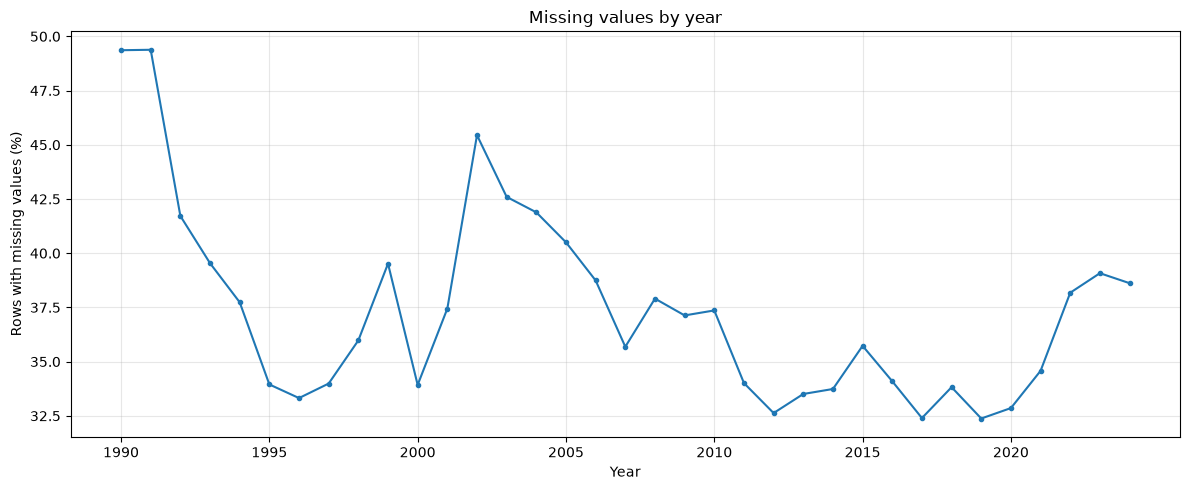

In [20]:
nr = 5
df = df_dict[keys[nr]]
null_overview = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_percent": (df.isna().mean() * 100).round(2),
})
null_overview = null_overview[null_overview["null_count"] > 0].sort_values(
    "null_count", ascending=False
)

import matplotlib.pyplot as plt

year_cols = [col for col in df.columns if col.startswith("Y")]
null_percent_by_year = df[year_cols].isna().mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_cols, null_percent_by_year, marker="o", markersize=3)
ax.set_title("Missing values by year")
ax.set_xlabel("Year")
ax.set_ylabel("Rows with missing values (%)")
ax.set_xticks(range(0, len(year_cols), 5))
ax.set_xticklabels([year_cols[i][1:] for i in range(0, len(year_cols), 5)])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()